Helpful Resources:

https://pypsa.org
https://docs.pypsa.org/latest/user-guide/components/storage-units/
https://docs.pypsa.org/latest/examples/example-1/


In [4]:
import pypsa
import numpy as np
import pandas as pd

We will begin by creating a simple test network and exploring the different components within pypsa.

In [54]:
#create the network itself
n = pypsa.Network()

The first component you will always start with is the Bus. This is the most basic unit of the nework and is what actually makes up all of the nodes within the network. All other components will attach to the bus. 

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x14587e334d0>},
 'branches': {},
 'flows': {}}

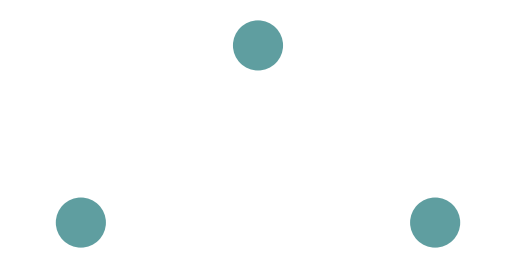

In [55]:
n.add("Bus",["bus1","bus2","bus3"],v_nom=11)
#Here we are adding 3 buses at the same time, so we pass 3 different names in a list.
n.plot(margin = 0.2)

Now that we have the nodes we can start populating them with the actual components of the network. 
The most basic ones we will focus on are:
- Generators
- Loads
- Lines (notably not Links)

Using these you can create a minimal viable network.
https://docs.pypsa.org/latest/user-guide/components/buses/

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x14589961590>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x14589962c10>},
 'flows': {}}

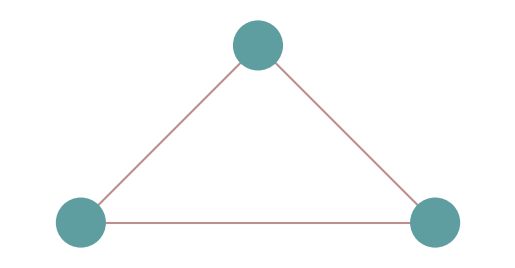

In [61]:

#create the network itself
n = pypsa.Network()

n.add("Bus",["bus1","bus2","bus3"],v_nom=11)

n.add(
    "Generator", #specify the type of the component added
      ["gen1","gen2","gen3"], #names of the components
      bus = ["bus1","bus2","bus3"], # buses to attach to
      p_nom = [200,100,350], #maximum power output (MW)
      marginal_cost = [5,4,7] #marginal cost (duh) €/MW
      )

n.add(
    "Load",#component type
    ["load1", "load2", "load3"], #name of components
    bus=["bus1", "bus2", "bus3"], #buses to attach to
    p_set=[50, 60, 300], #power demand
)

n.add(
    "Line",
    ["b1_b2","b2_b3","b3_b1"],
    bus0=["bus1", "bus2", "bus3"],#origin bus
    bus1=["bus2", "bus3", "bus1"],#destination bus (thought lines are bidirectional)
    s_nom=[200, 200, 200], #power rating in MW
    x=[0.02,0.02,0.01], #reactance (passing in single number means itll be the same across all 3 of them)
    r=0.01, #resistance
    
)

n.plot(margin = 0.2)


In [27]:
n.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
bus1,1.0,,0.0,0.0,AC,,,1.0,0.0,inf,Slack,gen1,0
bus2,1.0,,0.0,0.0,AC,,,1.0,0.0,inf,PQ,,0
bus3,1.0,,0.0,0.0,AC,,,1.0,0.0,inf,PQ,,0


In [28]:
n.loads

,bus,carrier,type,p_set,q_set,sign,active
name,,,,,,,
load1,bus1,,,5.0,0.0,-1.0,True
load2,bus2,,,6.0,0.0,-1.0,True
load3,bus3,,,30.0,0.0,-1.0,True


In [14]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,capital_cost_piecewise_opt
name,,,,,,,,,,,,,,,,,,,,,
b1_b2,bus1,bus2,,0.02,0.01,0.0,0.0,20.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
b2_b3,bus2,bus3,,0.02,0.01,0.0,0.0,20.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
b3_b1,bus3,bus1,,0.02,0.01,0.0,0.0,20.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Now that the network is built we can optimise it. In this case it simply means finding the configuration that satisfies all the demand from the loads for the lowest cost possible.

In [62]:
n.optimize()

C:\Users\artem\AppData\Local\Temp\ipykernel_21256\1261279110.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
Index(['bus1', 'bus2', 'bus3'], dtype='object', name='name')
Index(['b1_b2', 'b2_b3', 'b3_b1'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6 primals, 16 duals
Objective: 2.17e+03
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltag

('ok', 'optimal')

Having optimised the network we can now access the actual optimal power outputs and other useful information

In [63]:
n.generators_t.p #actual generator output

name,gen1,gen2,gen3
snapshot,,,
now,200.0,100.0,110.0


In [64]:
n.lines_t.p1 #power flow in the lines

name,b1_b2,b2_b3,b3_b1
snapshot,,,
now,-14.0,-54.0,136.0


Okay, great now lets examine a slightly larger example.
Below we see an example of loading a network from a series of csv files containing all the relevant data.
We will use this as a toy model example of dispatch down due to constraint. 

C:\Users\artem\AppData\Local\Temp\ipykernel_26948\1119856611.py:41: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
Index(['wind_bus1', 'wind_bus2', 'wind_bus3', 'gas_bus1', 'gas_bus2',
       'gas_bus3', 'load_bus1', 'load_bus2', 'load_bus3', 'load_bus4',
       'load_bus5'],
      dtype='object', name='name')
Index(['wind_gen1', 'wind_gen2', 'wind_gen3', 'gas_gen1', 'gas_gen2',
       'gas_gen3'],
      dtype='object', name='name')
Index(['w_link1', 'w_link2', 'w_link3', 'lo_link1', 'lo_link2', 'lo_link3',
       'lo_link4', 'lo_link5', 'g_link1', 'g_link2', 'g_link3', 'g_link4',
       'big_link'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.const

{'wind_bus1': 'green', 'wind_bus2': 'green', 'wind_bus3': 'green', 'gas_bus1': 'red', 'gas_bus2': 'red', 'gas_bus3': 'red', 'load_bus1': 'blue', 'load_bus2': 'blue', 'load_bus3': 'blue', 'load_bus4': 'blue', 'load_bus5': 'blue'}


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x2227748b750>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x2227748b9d0>},
 'flows': {}}

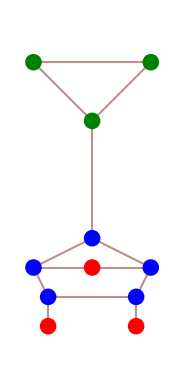

In [14]:
#Initialise the network
n=pypsa.Network()

#import all the data about components
buses = pd.read_csv("buses.csv").set_index("name")
generators = pd.read_csv("generators.csv").set_index("name")
loads = pd.read_csv("loads.csv").set_index("name")
lines = pd.read_csv("lines.csv").set_index("name")


#add them to the network
n.add("Bus",
      name = buses.index,
      x = buses["x"],
      y = buses["y"],
      v_nom = buses["v_nom"],
      )

n.add("Generator",
      name = generators.index,
      bus = generators["bus"], 
      carrier = generators["carrier"], #here we added a new field to specify the kind of energy generation (wing vs gas)
      p_nom = generators["p_nom"],
      marginal_cost = generators["marg_cost"]
      )
n.add("Load",
      name = loads.index,
      bus = loads["bus"],
      p_set = loads["p_set"]
      )
n.add("Line",
      name = lines.index,
      bus0 = lines["bus0"],
      bus1 = lines["bus1"],
      r = lines["r"],
      x = lines["x"],
      s_nom = lines["s_nom"]
      )

#run the optimisation to determine the actual power usage of things
n.optimize()

###plotting things
wind_buses = n.generators.loc[n.generators.carrier == "wind"].bus

load_buses = n.loads["bus"]
gas_buses = n.generators.loc[n.generators.carrier == "gas"].bus

bus_colours = {}
for bus in wind_buses:
    bus_colours[bus] = "green"

for bus in gas_buses:
    bus_colours[bus] = "red"

for bus in load_buses:
    bus_colours[bus] = "blue"

print(bus_colours)

n.plot(margin = 0.2,bus_color = bus_colours)

We see from the diagram above that the Wind turbines (in green) is only connected to the main sector of loads by one singular interconnector.

In [67]:
n.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
wind_bus1,11.0,,0.00,1.0,AC,,,1.0,0.0,inf,Slack,wind_gen1,0
wind_bus2,11.0,,1.00,2.0,AC,,,1.0,0.0,inf,PQ,,0
wind_bus3,11.0,,-1.00,2.0,AC,,,1.0,0.0,inf,PQ,,0
gas_bus1,11.0,,0.75,-2.5,AC,,,1.0,0.0,inf,PQ,,0
gas_bus2,11.0,,-0.75,-2.5,AC,,,1.0,0.0,inf,PQ,,0
gas_bus3,11.0,,0.00,-1.5,AC,,,1.0,0.0,inf,PQ,,0
load_bus1,11.0,,0.00,-1.0,AC,,,1.0,0.0,inf,PQ,,0
load_bus2,11.0,,1.00,-1.5,AC,,,1.0,0.0,inf,PQ,,0
load_bus3,11.0,,0.75,-2.0,AC,,,1.0,0.0,inf,PQ,,0


In [68]:
n.loads

,bus,carrier,type,p_set,q_set,sign,active
name,,,,,,,
load1,load_bus1,,,10.0,0.0,-1.0,True
load2,load_bus2,,,10.0,0.0,-1.0,True
load3,load_bus3,,,10.0,0.0,-1.0,True
load4,load_bus4,,,10.0,0.0,-1.0,True
load5,load_bus5,,,10.0,0.0,-1.0,True


In [69]:
n.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt,capital_cost_piecewise_opt
name,,,,,,,,,,,,,,,,,,,,,
wind_gen1,wind_bus1,Slack,,8.0,0.0,False,0.0,inf,NaN,0.0,...,0,1,0,NaN,NaN,NaN,NaN,1.0,8.0,0.0
wind_gen2,wind_bus2,PQ,,8.0,0.0,False,0.0,inf,NaN,0.0,...,0,1,0,NaN,NaN,NaN,NaN,1.0,8.0,0.0
wind_gen3,wind_bus3,PQ,,8.0,0.0,False,0.0,inf,NaN,0.0,...,0,1,0,NaN,NaN,NaN,NaN,1.0,8.0,0.0
gas_gen1,gas_bus1,PQ,,15.0,0.0,False,0.0,inf,NaN,0.0,...,0,1,0,NaN,NaN,NaN,NaN,1.0,15.0,0.0
gas_gen2,gas_bus2,PQ,,15.0,0.0,False,0.0,inf,NaN,0.0,...,0,1,0,NaN,NaN,NaN,NaN,1.0,15.0,0.0
gas_gen3,gas_bus3,PQ,,15.0,0.0,False,0.0,inf,NaN,0.0,...,0,1,0,NaN,NaN,NaN,NaN,1.0,15.0,0.0


In [16]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,capital_cost_piecewise_opt,v_nom
name,,,,,,,,,,,,,,,,,,,,,
w_link1,wind_bus1,wind_bus2,,0.02,0.01,0.0,0.0,6.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,6.0,0.0,11.0
w_link2,wind_bus2,wind_bus3,,0.02,0.01,0.0,0.0,6.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,6.0,0.0,11.0
w_link3,wind_bus3,wind_bus1,,0.02,0.01,0.0,0.0,6.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,6.0,0.0,11.0
lo_link1,load_bus1,load_bus2,,0.02,0.01,0.0,0.0,10.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,10.0,0.0,11.0
lo_link2,load_bus2,load_bus3,,0.02,0.01,0.0,0.0,10.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,10.0,0.0,11.0
lo_link3,load_bus3,load_bus4,,0.02,0.01,0.0,0.0,10.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,10.0,0.0,11.0
lo_link4,load_bus4,load_bus5,,0.02,0.01,0.0,0.0,10.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,10.0,0.0,11.0
lo_link5,load_bus5,load_bus1,,0.02,0.01,0.0,0.0,10.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,10.0,0.0,11.0
g_link1,gas_bus1,load_bus3,,0.02,0.01,0.0,0.0,20.0,0.0,False,...,0,0.000165,0.000083,0.0,0.0,0.000165,0.000083,20.0,0.0,11.0


In [15]:
n.generators_t.p

name,wind_gen1,wind_gen2,wind_gen3,gas_gen1,gas_gen2,gas_gen3
snapshot,,,,,,
now,10.0,8.0,2.0,10.0,20.0,-0.0


We see that despite benig able to produce more power at 0 extra cost, 8MW of wind energy across generators 1 and 3 are not being used to power the grid, instead being covered by the gas generators. We can see the reason for this by looking more closely at the power flow in the lines

In [77]:
n.lines_t.p0

name,w_link1,w_link2,w_link3,lo_link1,lo_link2,lo_link3,lo_link4,lo_link5,g_link1,g_link2,g_link3,g_link4,big_link
snapshot,,,,,,,,,,,,,
now,-6.0,2.0,4.0,3.0,-2.0,-0.0,2.0,-3.0,12.0,12.0,5.0,5.0,16.0


Wind is inconsistent and changes with time outside of our control. Therefore you might want to model how your network behaves across time. This can be done by introducing snapshots.

C:\Users\artem\AppData\Local\Temp\ipykernel_26948\1789192960.py:43: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
Index(['wind_bus1', 'wind_bus2', 'wind_bus3', 'gas_bus1', 'gas_bus2',
       'gas_bus3', 'load_bus1', 'load_bus2', 'load_bus3', 'load_bus4',
       'load_bus5'],
      dtype='object', name='name')
Index(['wind_gen1', 'wind_gen2', 'wind_gen3', 'gas_gen1', 'gas_gen2',
       'gas_gen3'],
      dtype='object', name='name')
Index(['w_link1', 'w_link2', 'w_link3', 'lo_link1', 'lo_link2', 'lo_link3',
       'lo_link4', 'lo_link5', 'g_link1', 'g_link2', 'g_link3', 'g_link4',
       'big_link'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.const

{'wind_bus1': 'green', 'wind_bus2': 'green', 'wind_bus3': 'green', 'gas_bus1': 'red', 'gas_bus2': 'red', 'gas_bus3': 'red', 'load_bus1': 'blue', 'load_bus2': 'blue', 'load_bus3': 'blue', 'load_bus4': 'blue', 'load_bus5': 'blue'}


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x2227741ad50>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x2227741afd0>},
 'flows': {}}

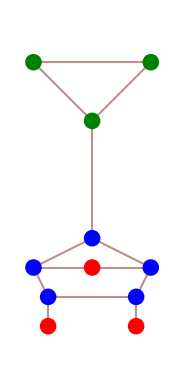

In [8]:
#Initialise the network
n=pypsa.Network()

#import all the data about components
buses = pd.read_csv("buses.csv").set_index("name")
generators = pd.read_csv("generators.csv").set_index("name")
loads = pd.read_csv("loads.csv").set_index("name")
lines = pd.read_csv("lines.csv").set_index("name")
time_profiles = pd.read_csv("generators-pmax_pu.csv") #load in an additional csv to represent a time dependent max wind capacity

n.set_snapshots(range(time_profiles.shape[0]))
time_profiles.reindex(n.snapshots)
#add them to the network
n.add("Bus",
      name = buses.index,#["name"],
      x = buses["x"],
      y = buses["y"],
      v_nom = buses["v_nom"],
      )
n.add("Generator",
      name = generators.index,#["name"],
      bus = generators["bus"], 
      carrier = generators["carrier"],
      p_nom = generators["p_nom"],
      marginal_cost = generators["marg_cost"],
      p_max_pu = time_profiles #and add the time dependent capacity to the generators
      )
n.add("Load",
      name = loads.index,#["name"],
      bus = loads["bus"],
      p_set = loads["p_set"]
      )
n.add("Line",
      name = lines.index,#["name"],
      bus0 = lines["bus0"],
      bus1 = lines["bus1"],
      r = lines["r"],
      x = lines["x"],
      s_nom = lines["s_nom"]
      )

#run the optimisation to determine the actual power usage of things
n.optimize()

###plotting shit
wind_buses = n.generators.loc[n.generators.carrier == "wind"].bus

load_buses = n.loads["bus"]
gas_buses = n.generators.loc[n.generators.carrier == "gas"].bus

bus_colours = {}
for bus in wind_buses:
    bus_colours[bus] = "green"

for bus in gas_buses:
    bus_colours[bus] = "red"

for bus in load_buses:
    bus_colours[bus] = "blue"

print(bus_colours)

n.plot(margin = 0.2,bus_color = bus_colours)

In [9]:
display(time_profiles)
display(n.generators_t.p)
display(n.lines_t.p0)

,wind_gen1,wind_gen2,wind_gen3,gas_gen1,gas_gen2,gas_gen3
0,0.1,0.1,0.1,1,1,1
1,0.3,0.3,0.3,1,1,1
2,0.5,0.5,0.5,1,1,1
3,0.7,0.7,0.7,1,1,1
4,0.9,0.9,0.9,1,1,1
5,1.0,1.0,1.0,1,1,1
6,1.0,1.0,1.0,1,1,1
7,1.0,1.0,1.0,1,1,1
8,1.0,1.0,1.0,1,1,1
9,1.0,1.0,1.0,1,1,1


name,wind_gen1,wind_gen2,wind_gen3,gas_gen1,gas_gen2,gas_gen3
snapshot,,,,,,
0,1.0,1.0,1.0,20.0,20.0,7.0
1,3.0,3.0,3.0,20.0,20.0,1.0
2,5.0,5.0,5.0,15.0,20.0,-0.0
3,7.0,6.0,6.0,20.0,11.0,-0.0
4,9.0,4.0,7.0,10.0,20.0,-0.0
5,10.0,2.0,8.0,10.0,20.0,-0.0
6,8.0,6.0,6.0,10.0,20.0,-0.0
7,10.0,8.0,2.0,20.0,10.0,-0.0
8,10.0,8.0,2.0,10.0,20.0,-0.0


name,w_link1,w_link2,w_link3,lo_link1,lo_link2,lo_link3,lo_link4,lo_link5,g_link1,g_link2,g_link3,g_link4,big_link
snapshot,,,,,,,,,,,,,
0,-1.0,-0.0,1.0,-3.5000,-10.000,-0.000,10.000,3.5000,20.0,20.0,3.5000,3.5000,3.0
1,-3.0,-0.0,3.0,-0.5000,-10.000,-0.000,10.000,0.5000,20.0,20.0,0.5000,0.5000,9.0
2,-5.0,-0.0,5.0,2.8125,-6.875,-1.875,8.125,-2.1875,15.0,20.0,-0.3125,0.3125,15.0
3,-6.0,-0.0,6.0,3.9375,-6.625,3.375,4.375,-5.0625,20.0,11.0,0.5625,-0.5625,19.0
4,-5.0,-1.0,6.0,5.6250,-3.750,-3.750,6.250,-4.3750,10.0,20.0,-0.6250,0.6250,20.0
5,-4.0,-2.0,6.0,5.6250,-3.750,-3.750,6.250,-4.3750,10.0,20.0,-0.6250,0.6250,20.0
6,-6.0,-0.0,6.0,5.6250,-3.750,-3.750,6.250,-4.3750,10.0,20.0,-0.6250,0.6250,20.0
7,-6.0,2.0,4.0,4.3750,-6.250,3.750,3.750,-5.6250,20.0,10.0,0.6250,-0.6250,20.0
8,-6.0,2.0,4.0,5.6250,-3.750,-3.750,6.250,-4.3750,10.0,20.0,-0.6250,0.6250,20.0


You can see that at snapshots 2-6 wind power is constrained by the "big_link" power line reaching its full thermal rating. We can try to remedy this by adding in a storage unit.

C:\Users\artem\AppData\Local\Temp\ipykernel_26948\319702245.py:69: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
Index(['wind_bus1', 'wind_bus2', 'wind_bus3', 'gas_bus1', 'gas_bus2',
       'gas_bus3', 'load_bus1', 'load_bus2', 'load_bus3', 'load_bus4',
       'load_bus5', 'storage_bus'],
      dtype='object', name='name')
Index(['wind_gen1', 'wind_gen2', 'wind_gen3', 'gas_gen1', 'gas_gen2',
       'gas_gen3'],
      dtype='object', name='name')
Index(['w_link1', 'w_link2', 'w_link3', 'lo_link1', 'lo_link2', 'lo_link3',
       'lo_link4', 'lo_link5', 'g_link1', 'g_link2', 'g_link3', 'g_link4',
       'big_link', 'stor_w1', 'stor_w2', 'stor_w3'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:l

{'wind_bus1': 'green', 'wind_bus2': 'green', 'wind_bus3': 'green', 'gas_bus1': 'red', 'gas_bus2': 'red', 'gas_bus3': 'red', 'load_bus1': 'blue', 'load_bus2': 'blue', 'load_bus3': 'blue', 'load_bus4': 'blue', 'load_bus5': 'blue', 'storage_bus': 'purple'}


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x222774dc410>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x222774dc690>},
 'flows': {}}

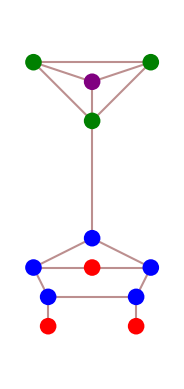

In [11]:
#Initialise the network
n=pypsa.Network()

#import all the data about components
buses = pd.read_csv("buses.csv").set_index("name")
generators = pd.read_csv("generators.csv").set_index("name")
loads = pd.read_csv("loads.csv").set_index("name")
lines = pd.read_csv("lines.csv").set_index("name")
time_profiles = pd.read_csv("generators-pmax_pu.csv") #load in an additional csv to represent a time dependent max wind capacity

n.set_snapshots(range(time_profiles.shape[0]))
time_profiles.reindex(n.snapshots)
#add them to the network
n.add("Bus",
      name = buses.index,#["name"],
      x = buses["x"],
      y = buses["y"],
      v_nom = buses["v_nom"],
      )
n.add("Generator",
      name = generators.index,#["name"],
      bus = generators["bus"], 
      carrier = generators["carrier"],
      p_nom = generators["p_nom"],
      marginal_cost = generators["marg_cost"],
      p_max_pu = time_profiles #and add the time dependent capacity to the generators
      )
n.add("Load",
      name = loads.index,#["name"],
      bus = loads["bus"],
      p_set = loads["p_set"]
      )
n.add("Line",
      name = lines.index,#["name"],
      bus0 = lines["bus0"],
      bus1 = lines["bus1"],
      r = lines["r"],
      x = lines["x"],
      s_nom = lines["s_nom"]
      )

###lets now add an extra bus to add storage in
n.add(
    "Bus",
    "storage_bus",
    x = 0,
    y= 5/3,
    vnom = 11)

n.add(
    "StorageUnit",
    name = "wind_store",
    bus = "storage_bus",
    p_nom = 10,
    max_hours = "3"
    )

n.add(
    "Line",
    name = ["stor_w1","stor_w2","stor_w3"],
    bus0 = "storage_bus",
    bus1 = ["wind_bus1","wind_bus2","wind_bus3"],
    x = 0.02,
    r = 0.01,
    s_nom = 10
)

#run the optimisation to determine the actual power usage of things
n.optimize()

###plotting shit
wind_buses = n.generators.loc[n.generators.carrier == "wind"].bus

load_buses = n.loads["bus"]
gas_buses = n.generators.loc[n.generators.carrier == "gas"].bus
store_buses = n.storage_units["bus"]

bus_colours = {}
for bus in wind_buses:
    bus_colours[bus] = "green"

for bus in gas_buses:
    bus_colours[bus] = "red"

for bus in load_buses:
    bus_colours[bus] = "blue"

for bus in store_buses:
    bus_colours[bus] = "purple"

print(bus_colours)

n.plot(margin = 0.2,bus_color = bus_colours)

In [12]:
display(time_profiles)
display(n.generators_t.p)
display(n.lines_t.p0)

,wind_gen1,wind_gen2,wind_gen3,gas_gen1,gas_gen2,gas_gen3
0,0.1,0.1,0.1,1,1,1
1,0.3,0.3,0.3,1,1,1
2,0.5,0.5,0.5,1,1,1
3,0.7,0.7,0.7,1,1,1
4,0.9,0.9,0.9,1,1,1
5,1.0,1.0,1.0,1,1,1
6,1.0,1.0,1.0,1,1,1
7,1.0,1.0,1.0,1,1,1
8,1.0,1.0,1.0,1,1,1
9,1.0,1.0,1.0,1,1,1


name,wind_gen1,wind_gen2,wind_gen3,gas_gen1,gas_gen2,gas_gen3
snapshot,,,,,,
0,1.0,1.000000,1.000000,20.000000,20.000000,7.0
1,3.0,3.000000,3.000000,20.000000,20.000000,1.0
2,5.0,5.000000,5.000000,20.000000,15.000000,-0.0
3,7.0,6.016529,6.016529,20.000000,10.966942,-0.0
4,9.0,3.950413,7.049587,10.000000,20.000000,-0.0
5,10.0,1.950413,8.049587,20.000000,10.000000,-0.0
6,10.0,8.049587,7.454545,10.000000,20.000000,-0.0
7,10.0,8.049587,8.049587,20.000000,10.000000,-0.0
8,10.0,8.049587,8.049587,20.000000,10.000000,-0.0


name,w_link1,w_link2,w_link3,lo_link1,lo_link2,lo_link3,lo_link4,lo_link5,g_link1,g_link2,g_link3,g_link4,big_link,stor_w1,stor_w2,stor_w3
snapshot,,,,,,,,,,,,,,,,
0,-0.997253,-0.000000e+00,0.997253,-3.500000,-10.000000,-0.000000,10.000000,3.500000,20.000000,20.000000,3.500000,3.500000,3.000000,0.005495,-0.002747,-0.002747
1,-2.991758,-0.000000e+00,2.991758,-0.500000,-10.000000,-0.000000,10.000000,0.500000,20.000000,20.000000,0.500000,0.500000,9.000000,0.016484,-0.008242,-0.008242
2,-4.986264,-0.000000e+00,4.986264,2.187500,-8.125000,1.875000,6.875000,-2.812500,20.000000,15.000000,0.312500,-0.312500,15.000000,0.027473,-0.013736,-0.013736
3,-6.000000,-0.000000e+00,6.000000,3.951963,-6.612603,3.387397,4.354339,-5.081095,20.000000,10.966942,0.564566,-0.564566,19.033058,0.033058,-0.016529,-0.016529
4,-4.969780,-1.030220e+00,6.000000,5.625000,-3.750000,-3.750000,6.250000,-4.375000,10.000000,20.000000,-0.625000,0.625000,20.000000,0.030220,-0.010853,-0.019367
5,-3.972527,-2.027473e+00,6.000000,4.375000,-6.250000,3.750000,3.750000,-5.625000,20.000000,10.000000,0.625000,-0.625000,20.000000,0.027473,-0.005358,-0.022114
6,-6.000000,1.978022e-01,5.802198,5.625000,-3.750000,-3.750000,6.250000,-4.375000,10.000000,20.000000,-0.625000,0.625000,20.000000,-1.802198,-1.851785,-1.850150
7,-6.000000,-0.000000e+00,6.000000,4.375000,-6.250000,3.750000,3.750000,-5.625000,20.000000,10.000000,0.625000,-0.625000,20.000000,-2.000000,-2.049587,-2.049587
8,-6.000000,-0.000000e+00,6.000000,4.375000,-6.250000,3.750000,3.750000,-5.625000,20.000000,10.000000,0.625000,-0.625000,20.000000,-2.000000,-2.049587,-2.049587


In [13]:
n.storage_units_t.p

name,wind_store
snapshot,
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,-5.504132
7,-6.099174
8,-6.099174


In your github repositories you may have noticed .nc files and rightly questioned what they are and how to open them. 
.nc files allow you to load a network directly into PyPSA without having to manually add all of the components.
For instance:

INFO:pypsa.network.io:Imported network 'TYTFS2024_SV2024_V35 (transmission)' has buses, carriers, generators, lines, links, loads, sub_networks, transformers


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x14589ca3ed0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x14589d20050>,
  'Line': <matplotlib.collections.LineCollection at 0x14589d20190>,
  'Transformer': <matplotlib.collections.LineCollection at 0x14589d202d0>},
 'flows': {}}

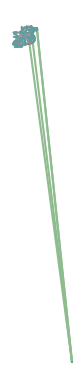

In [78]:
n = pypsa.Network("SV2024_all-island.nc")

n.plot()

In [80]:
n.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,...,sub_network,psse_type,area,zone,v_ang_psse,has_coordinates,psse_name,station,jurisdiction,coordinate_source
name,,,,,,,,,,,,,,,,,,,,,
1021,110.0,,-8.616369,52.704987,AC,,,1.03004,0.0,inf,...,0,1.0,4.0,4.0,4.1586,True,ARDNACRUSHA,ARDNACRUSHA,IE,geocoded
1041,110.0,,-8.227215,51.835638,AC,,,1.01103,0.0,inf,...,0,1.0,10.0,10.0,14.6099,True,AGHADA,AGHADA,IE,geocoded
1042,220.0,,-8.227215,51.835638,AC,,,1.00000,0.0,inf,...,0,1.0,10.0,10.0,18.0255,True,AGHADA,AGHADA,IE,geocoded
1052,220.0,,-8.229869,51.832479,AC,,,1.00000,0.0,inf,...,0,1.0,10.0,10.0,18.0255,True,AGHADA_B,AGHADA_B,IE,geocoded
1061,110.0,,-8.075512,54.094570,AC,,,1.05564,0.0,inf,...,0,1.0,1.0,1.0,-4.4872,True,ARIGNA,ARIGNA,IE,geocoded
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
star:90012-90020-90063-1,110.0,,-6.425216,54.370095,AC,,,1.00806,0.0,inf,...,0,1.0,NaN,NaN,-4.5768,False,star of 90012-90020-90063-1,STAR,--,star point
star:90310-90320-90361-1,110.0,,-6.681679,54.511946,AC,,,1.04164,0.0,inf,...,0,1.0,NaN,NaN,-4.0605,False,star of 90310-90320-90361-1,STAR,--,star point
star:90310-90320-90362-1,110.0,,-6.681679,54.511946,AC,,,1.03901,0.0,inf,...,0,1.0,NaN,NaN,-4.0383,False,star of 90310-90320-90362-1,STAR,--,star point


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x14589dc0550>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x14589dc0690>,
  'Line': <matplotlib.collections.LineCollection at 0x14589dc07d0>,
  'Transformer': <matplotlib.collections.LineCollection at 0x14589ade710>},
 'flows': {}}

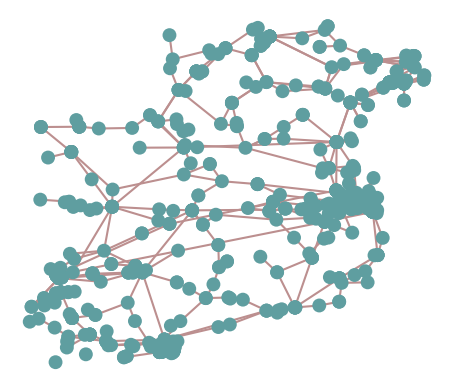

In [82]:
n.buses.drop(n.buses.loc[n.buses['y']== min(n.buses['y'])].index,inplace = True)
n.plot(bus_sizes=0.005)

You can use the pypsa as a way to read these files in and extract the data into dataframes, even if you won't use the actual grid optimisation features.

In [84]:
n.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt,capital_cost_piecewise_opt,psse_bus,aggregated,p_set_tytfs,psse_bus_name
name,,,,,,,,,,,,,,,,,,,,,
10470-1,10422,PV,,456.690000,0.0,False,0.0,inf,NaN,0.486107,...,NaN,NaN,NaN,1.0,0.0,0.0,10470.0,1.0,456.0,AGH_CCGT
27474-1,2742,PV,,464.500000,0.0,False,0.0,inf,NaN,0.505920,...,NaN,NaN,NaN,1.0,0.0,0.0,27474.0,1.0,350.0,GI CCGT
28571-1,2852,PV,,444.000000,0.0,False,0.0,inf,NaN,0.247973,...,NaN,NaN,NaN,1.0,0.0,0.0,28571.0,1.0,444.0,WHITEGATE
29673-2,2972,PV,,400.000000,0.0,False,0.0,inf,NaN,0.485000,...,NaN,NaN,NaN,1.0,0.0,0.0,29673.0,1.0,400.0,BS_HUNTSTOWN
31271-1,3122,PV,,406.900000,0.0,False,0.0,inf,NaN,0.400590,...,NaN,NaN,NaN,1.0,0.0,0.0,31271.0,1.0,199.0,DUBLIN_BAY_P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
shed 88012,88012,PQ,,33.375757,0.0,False,0.0,inf,NaN,0.000000,...,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,
shed 88512,88512,PQ,,21.639706,0.0,False,0.0,inf,NaN,0.000000,...,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,
shed 89311,89311,PQ,,21.050722,0.0,False,0.0,inf,NaN,0.000000,...,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,
